In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.feature_extraction.text import TfidfVectorizer

import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [4]:
df = pd.read_csv("will_games_sales_manchester.csv")

df.head()

,sale_id,customer_age,customer_gender,area,game_title,platform,price,cost,profit_margin,units_sold,review_text,purchase_date
0,1,21,M,Manchester City Centre,FIFA 23,PlayStation,59.99,40,19.99,1,Great football game with realistic gameplay,2024-01-03
1,2,34,F,Salford,Call of Duty MW3,Xbox,69.99,48,21.99,1,Amazing graphics but campaign is short,2024-01-04
2,3,28,M,Didsbury,Minecraft,Nintendo Switch,29.99,15,14.99,2,Very creative and relaxing game,2024-01-05
3,4,42,F,Stockport,The Sims 4,PC,39.99,20,19.99,1,Fun simulation but needs more expansion packs,2024-01-06
4,5,19,M,Oldham,GTA V,PlayStation,49.99,32,17.99,1,Still one of the best open world games,2024-01-06


In [5]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sale_id          10 non-null     int64  
 1   customer_age     10 non-null     int64  
 2   customer_gender  10 non-null     object 
 3   area             10 non-null     object 
 4   game_title       10 non-null     object 
 5   platform         10 non-null     object 
 6   price            10 non-null     float64
 7   cost             10 non-null     int64  
 8   profit_margin    10 non-null     float64
 9   units_sold       10 non-null     int64  
 10  review_text      10 non-null     object 
 11  purchase_date    10 non-null     object 
dtypes: float64(2), int64(4), object(6)
memory usage: 1.1+ KB


,sale_id,customer_age,price,cost,profit_margin,units_sold
count,10.00000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,5.50000,28.900000,50.990000,31.500000,19.490000,1.300000
std,3.02765,7.294595,19.692074,15.012957,5.038739,0.674949
min,1.00000,19.000000,9.990000,2.000000,7.990000,1.000000
25%,3.25000,23.500000,42.490000,22.500000,18.490000,1.000000
50%,5.50000,28.500000,54.990000,35.000000,19.990000,1.000000
75%,7.75000,33.250000,67.490000,43.750000,21.990000,1.000000
max,10.00000,42.000000,69.990000,48.000000,24.990000,3.000000


In [6]:
df["total_profit"] = df["profit_margin"] * df["units_sold"]

df.head()

,sale_id,customer_age,customer_gender,area,game_title,platform,price,cost,profit_margin,units_sold,review_text,purchase_date,total_profit
0,1,21,M,Manchester City Centre,FIFA 23,PlayStation,59.99,40,19.99,1,Great football game with realistic gameplay,2024-01-03,19.99
1,2,34,F,Salford,Call of Duty MW3,Xbox,69.99,48,21.99,1,Amazing graphics but campaign is short,2024-01-04,21.99
2,3,28,M,Didsbury,Minecraft,Nintendo Switch,29.99,15,14.99,2,Very creative and relaxing game,2024-01-05,29.98
3,4,42,F,Stockport,The Sims 4,PC,39.99,20,19.99,1,Fun simulation but needs more expansion packs,2024-01-06,19.99
4,5,19,M,Oldham,GTA V,PlayStation,49.99,32,17.99,1,Still one of the best open world games,2024-01-06,17.99


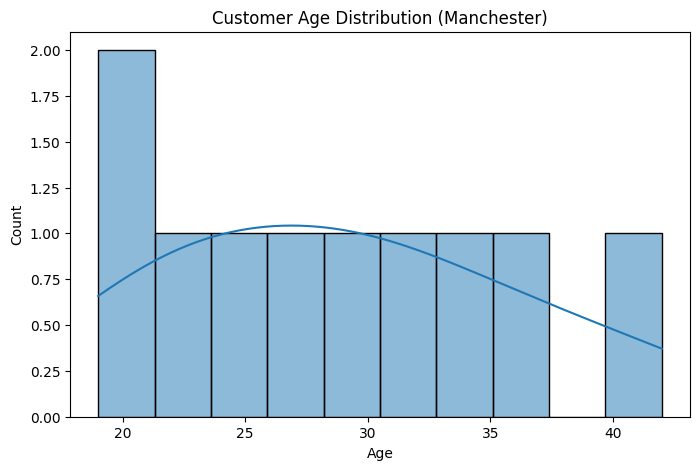

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["customer_age"], bins=10, kde=True)
plt.title("Customer Age Distribution (Manchester)")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

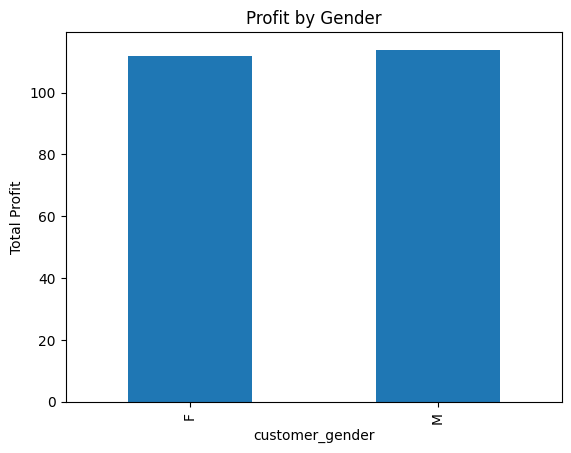

In [8]:
sales_gender = df.groupby("customer_gender")["total_profit"].sum()

sales_gender.plot(kind="bar")
plt.title("Profit by Gender")
plt.ylabel("Total Profit")
plt.show()

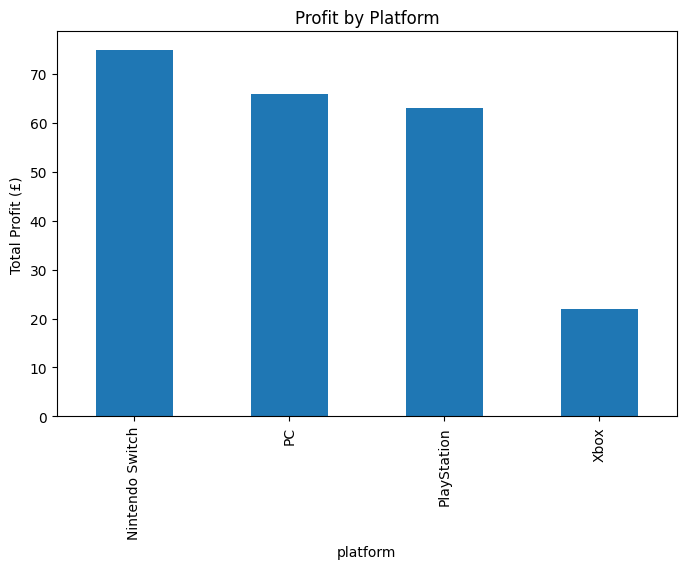

In [9]:
platform_profit = df.groupby("platform")["total_profit"].sum()

platform_profit.plot(kind="bar", figsize=(8,5))
plt.title("Profit by Platform")
plt.ylabel("Total Profit (£)")
plt.show()

In [10]:
X = df[["price", "cost", "customer_age", "units_sold"]]

y = df["profit_margin"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
y_pred = model.predict(X_test)

In [14]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 2.9187853493177437e-28
R2 Score: 1.0


In [15]:
vectorizer = TfidfVectorizer(stop_words="english")

X_text = vectorizer.fit_transform(df["review_text"])

print(X_text.shape)

(10, 32)


In [16]:
sia = SentimentIntensityAnalyzer()

df["sentiment_score"] = df["review_text"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

df[["review_text","sentiment_score"]]

,review_text,sentiment_score
0,Great football game with realistic gameplay,0.6249
1,Amazing graphics but campaign is short,0.3400
2,Very creative and relaxing game,0.7688
3,Fun simulation but needs more expansion packs,0.2846
4,Still one of the best open world games,0.6369
5,Cute relaxing game I play daily,0.8225
6,Very difficult but rewarding gameplay,0.6248
7,Story and graphics are fantastic,0.5574
8,Fun online battles with friends,0.5859
9,Huge world and amazing adventure,0.8126


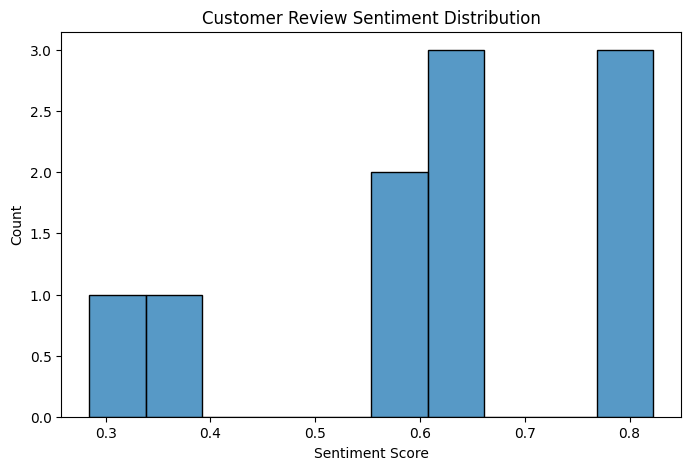

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df["sentiment_score"], bins=10)

plt.title("Customer Review Sentiment Distribution")
plt.xlabel("Sentiment Score")
plt.show()

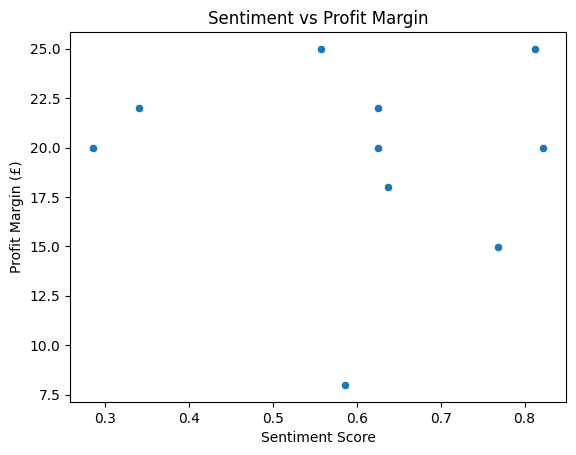

In [18]:
sns.scatterplot(x=df["sentiment_score"], y=df["profit_margin"])

plt.title("Sentiment vs Profit Margin")
plt.xlabel("Sentiment Score")
plt.ylabel("Profit Margin (£)")
plt.show()

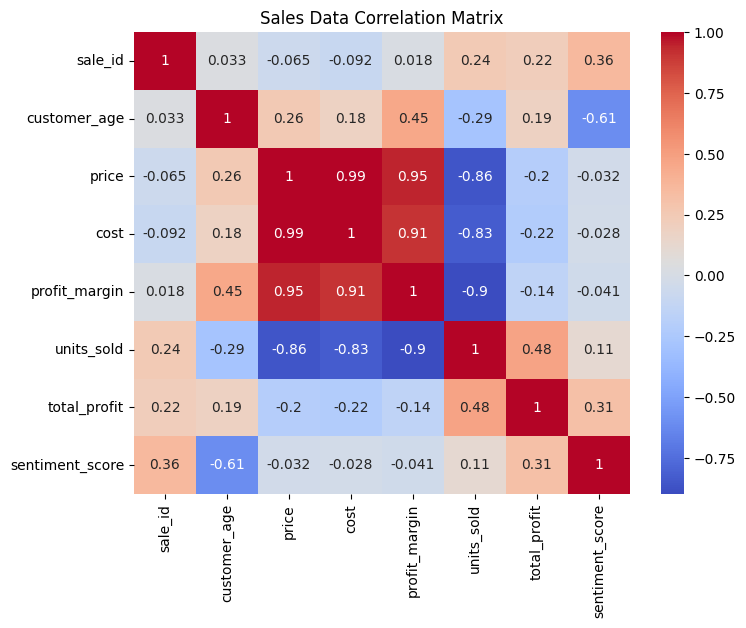

In [19]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Sales Data Correlation Matrix")

plt.show()